In [1]:
# ==========================================================
# Task 6 (Advanced): Data Science Business Intelligence Dashboard
# Cell 1: Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


In [2]:
# ==========================================================
# Cell 2: Load Dataset
# ==========================================================

DATA_PATH = r"C:\Users\bts\OneDrive\Desktop\Auspify\Dataset\Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

print("\nFirst 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

Dataset Loaded Successfully
Dataset Shape : (8790, 10)

First 5 Rows


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"



Last 5 Rows


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


In [3]:
# ==========================================================
# Cell 3: Dataset Overview
# ==========================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

display(df.info())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nMemory Usage")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"{memory:.2f} MB")

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 1.6 MB


None


Dataset Shape
(8790, 10)

Column Names
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Data Types


show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object


Memory Usage
1.55 MB


In [4]:
# ==========================================================
# Cell 4: Data Quality Report
# ==========================================================

quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2).values,
    "Unique Values": df.nunique().values
})

print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

display(quality_report)

print("\nDuplicate Records :", df.duplicated().sum())

DATA QUALITY REPORT


,Column,Data Type,Missing Values,Missing %,Unique Values
0,show_id,str,0,0.0,8790
1,type,str,0,0.0,2
2,title,str,0,0.0,8787
3,director,str,0,0.0,4528
4,country,str,0,0.0,86
5,date_added,str,0,0.0,1713
6,release_year,int64,0,0.0,74
7,rating,str,0,0.0,14
8,duration,str,0,0.0,220
9,listed_in,str,0,0.0,513



Duplicate Records : 0


In [5]:
# ==========================================================
# Cell 5: Data Cleaning
# ==========================================================

# Remove duplicate rows
duplicates = df.duplicated().sum()

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicates Removed : {duplicates}")

# Convert date_added to datetime
if "date_added" in df.columns:
    df["date_added"] = pd.to_datetime(
        df["date_added"],
        errors="coerce"
    )

# Convert release_year to integer
if "release_year" in df.columns:
    df["release_year"] = df["release_year"].astype(int)

print("\nUpdated Dataset Shape")
print(df.shape)

print("\nMissing Values After Cleaning")
display(df.isnull().sum())

Duplicates Removed : 0

Updated Dataset Shape
(8790, 10)

Missing Values After Cleaning


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [6]:
# ==========================================================
# Cell 6: Feature Engineering
# ==========================================================

CURRENT_YEAR = pd.Timestamp.now().year

# Content Age
if "release_year" in df.columns:
    df["content_age"] = CURRENT_YEAR - df["release_year"]

# Added Year
if "date_added" in df.columns:
    df["added_year"] = df["date_added"].dt.year
    df["added_month"] = df["date_added"].dt.month_name()
    df["added_quarter"] = df["date_added"].dt.quarter

# Movie Duration
if "duration" in df.columns:

    df["movie_duration"] = (
        df["duration"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

# Decade Feature
if "release_year" in df.columns:
    df["decade"] = (df["release_year"] // 10) * 10

print("=" * 60)
print("Feature Engineering Completed")
print("=" * 60)

new_features = [
    "content_age",
    "added_year",
    "added_month",
    "added_quarter",
    "movie_duration",
    "decade"
]

available_features = [col for col in new_features if col in df.columns]

display(df[available_features].head())

Feature Engineering Completed


,content_age,added_year,added_month,added_quarter,movie_duration,decade
0,6,2021,September,3,90.0,2020
1,5,2021,September,3,1.0,2020
2,5,2021,September,3,1.0,2020
3,5,2021,September,3,91.0,2020
4,33,2021,September,3,125.0,1990


In [7]:
# ==========================================================
# Cell 7: Descriptive Statistics
# ==========================================================

print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

print("\nNumerical Features")
display(df.describe().T)

print("\nCategorical Features")
display(df.describe(include=["object"]).T)

DESCRIPTIVE STATISTICS

Numerical Features


,count,mean,min,25%,50%,75%,max,std
date_added,8790,2019-05-17 21:44:01.638225,2008-01-01 00:00:00,2018-04-06 00:00:00,2019-07-03 00:00:00,2020-08-19 18:00:00,2021-09-25 00:00:00,NaN
release_year,8790.0,2014.183163,1925.0,2013.0,2017.0,2019.0,2021.0,8.825466
content_age,8790.0,11.816837,5.0,7.0,9.0,13.0,101.0,8.825466
added_year,8790.0,2018.873606,2008.0,2018.0,2019.0,2020.0,2021.0,1.573568
added_quarter,8790.0,2.553356,1.0,2.0,3.0,4.0,4.0,1.108849
movie_duration,8790.0,69.934471,1.0,2.0,88.5,106.0,312.0,50.794433
decade,8790.0,2009.110353,1920.0,2010.0,2010.0,2010.0,2020.0,9.235438



Categorical Features


,count,unique,top,freq
show_id,8790,8790,s1,1
type,8790,2,Movie,6126
title,8790,8787,9-Feb,2
director,8790,4528,Not Given,2588
country,8790,86,United States,3240
rating,8790,14,TV-MA,3205
duration,8790,220,1 Season,1791
listed_in,8790,513,"Dramas, International Movies",362
added_month,8790,12,July,827


In [8]:
# ==========================================================
# Cell 8: Business KPI Dashboard
# ==========================================================

print("=" * 70)
print("BUSINESS KEY PERFORMANCE INDICATORS")
print("=" * 70)

kpis = {
    "Total Titles": len(df),
    "Movies": (df["type"] == "Movie").sum(),
    "TV Shows": (df["type"] == "TV Show").sum(),
    "Unique Countries": df["country"].nunique() if "country" in df.columns else 0,
    "Unique Directors": df["director"].nunique() if "director" in df.columns else 0,
    "Unique Genres": df["listed_in"].nunique() if "listed_in" in df.columns else 0,
    "Earliest Release Year": df["release_year"].min(),
    "Latest Release Year": df["release_year"].max(),
    "Average Release Year": round(df["release_year"].mean(), 2)
}

kpi_df = pd.DataFrame(
    kpis.items(),
    columns=["Metric", "Value"]
)

display(kpi_df)

BUSINESS KEY PERFORMANCE INDICATORS


,Metric,Value
0,Total Titles,8790.00
1,Movies,6126.00
2,TV Shows,2664.00
3,Unique Countries,86.00
4,Unique Directors,4528.00
5,Unique Genres,513.00
6,Earliest Release Year,1925.00
7,Latest Release Year,2021.00
8,Average Release Year,2014.18


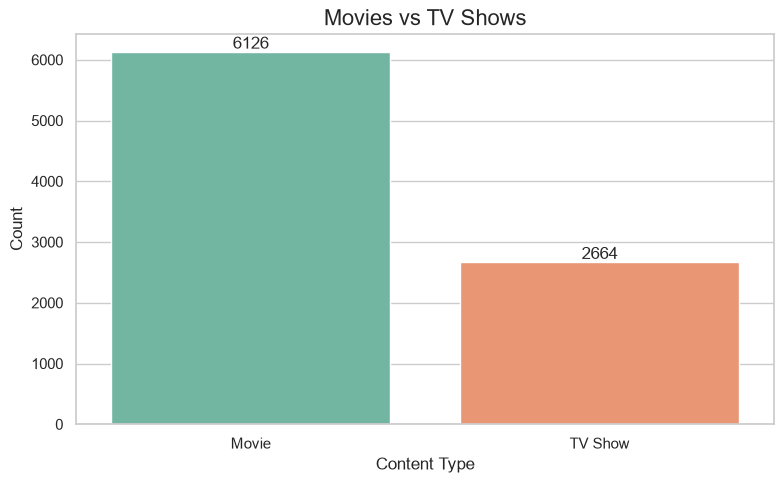

In [9]:
# ==========================================================
# Cell 9: Movies vs TV Shows
# ==========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    palette="Set2"
)

plt.title("Movies vs TV Shows", fontsize=16)
plt.xlabel("Content Type")
plt.ylabel("Count")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.tight_layout()
plt.show()

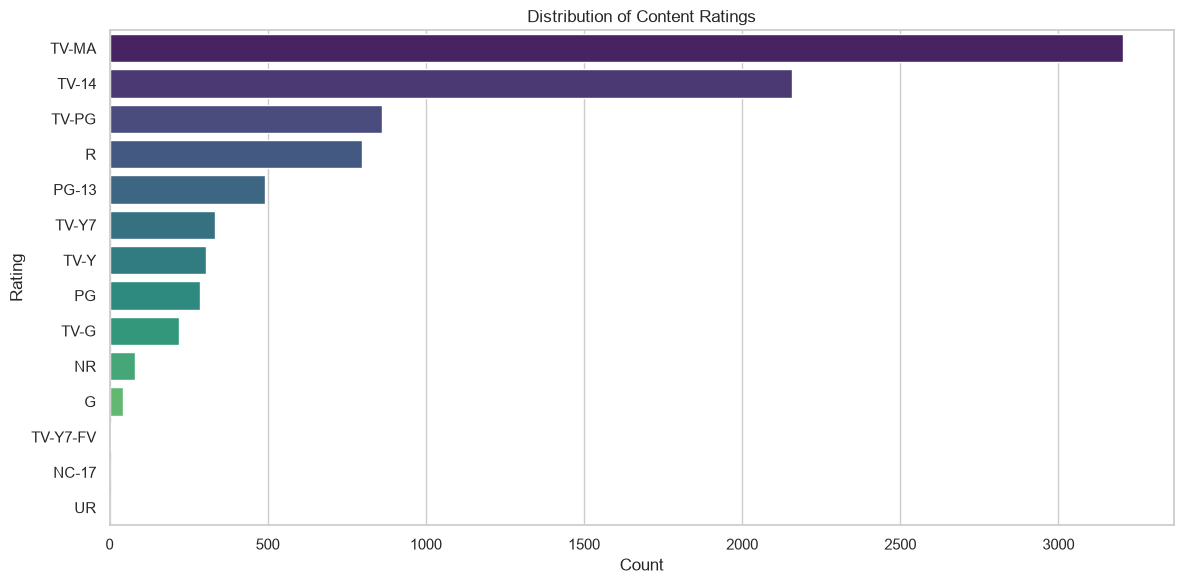

In [10]:
# ==========================================================
# Cell 10: Content Rating Distribution
# ==========================================================

plt.figure(figsize=(12, 6))

rating_order = df["rating"].value_counts().index

sns.countplot(
    data=df,
    y="rating",
    order=rating_order,
    palette="viridis"
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

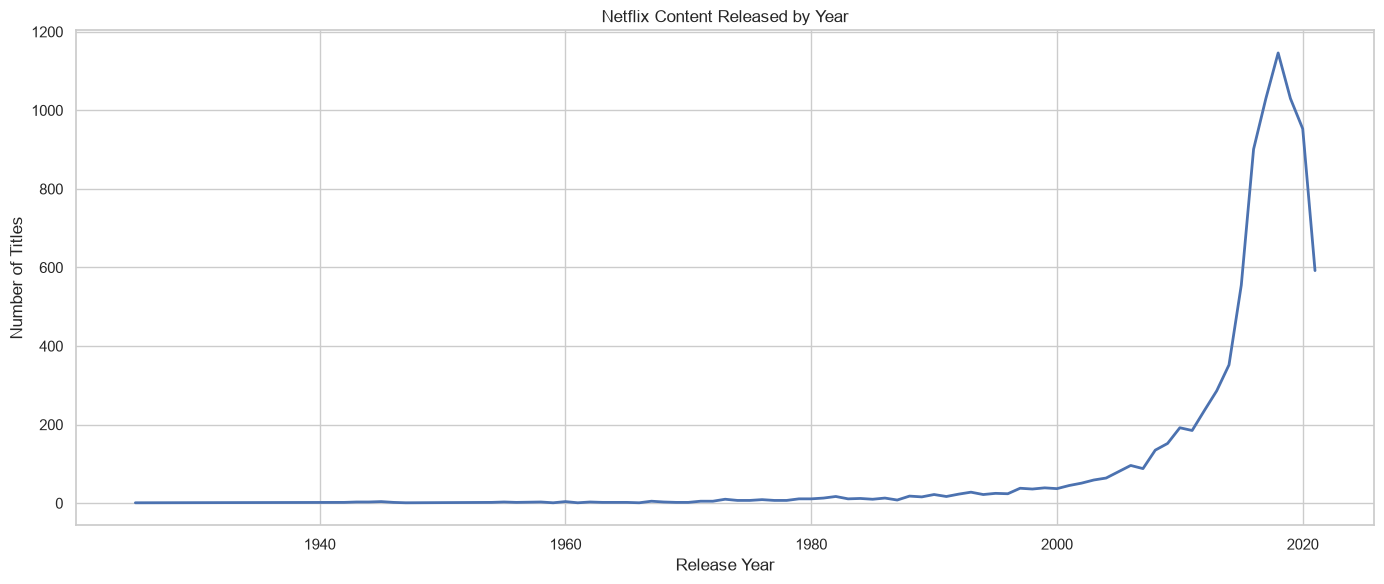

In [11]:
# ==========================================================
# Cell 11: Release Year Analysis
# ==========================================================

release_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    release_counts.index,
    release_counts.values,
    linewidth=2
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.tight_layout()
plt.show()

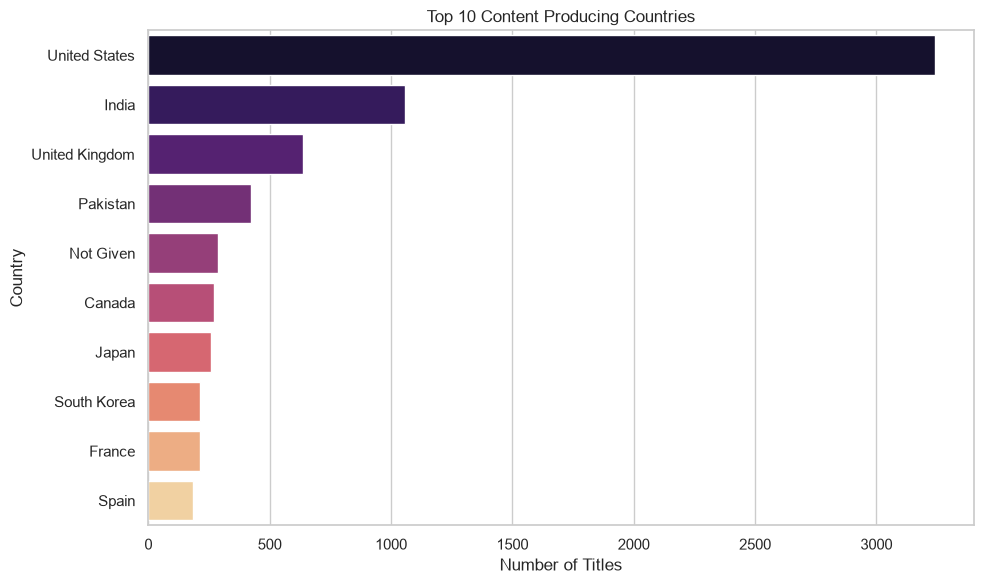

In [12]:
# ==========================================================
# Cell 12: Top 10 Producing Countries
# ==========================================================

country_data = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_countries = country_data.value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="magma"
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

TOP 10 CONTENT GENRES


,Genre,Number of Titles
0,International Movies,2752
1,Dramas,2426
2,Comedies,1674
3,International TV Shows,1349
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


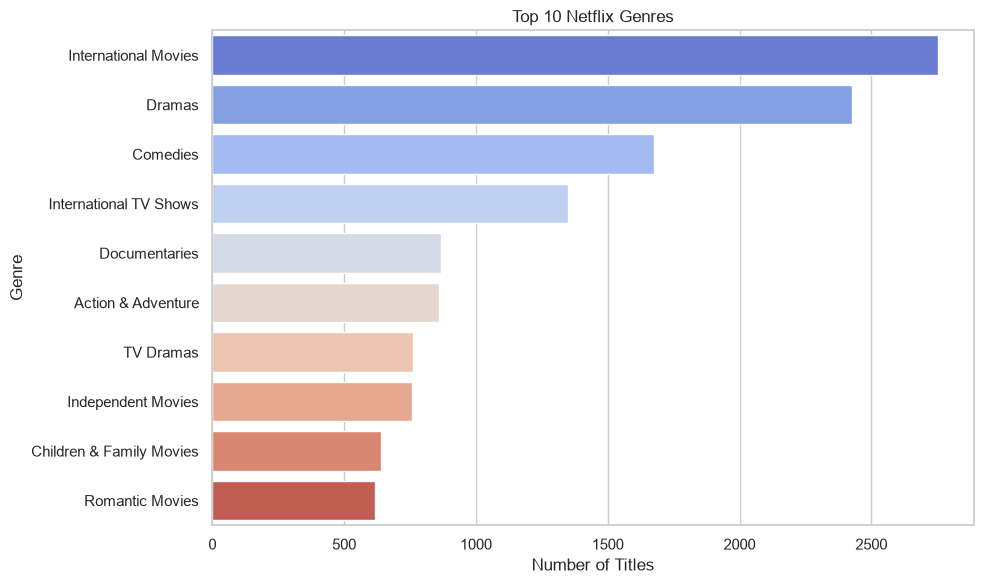

In [13]:
# ==========================================================
# Cell 13: Top 10 Genres Analysis
# ==========================================================

print("=" * 70)
print("TOP 10 CONTENT GENRES")
print("=" * 70)

# Split multiple genres
genre_data = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_genres = genre_data.value_counts().head(10)

display(
    top_genres.reset_index()
    .rename(columns={
        "listed_in":"Genre",
        "count":"Number of Titles"
    })
)


plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette="coolwarm"
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

TOP 10 DIRECTORS


,Director,Number of Titles
0,Not Given,2588
1,Rajiv Chilaka,23
2,Jan Suter,21
3,Alastair Fothergill,19
4,Raúl Campos,19
5,Suhas Kadav,16
6,Marcus Raboy,16
7,Jay Karas,15
8,Cathy Garcia-Molina,13
9,Youssef Chahine,12


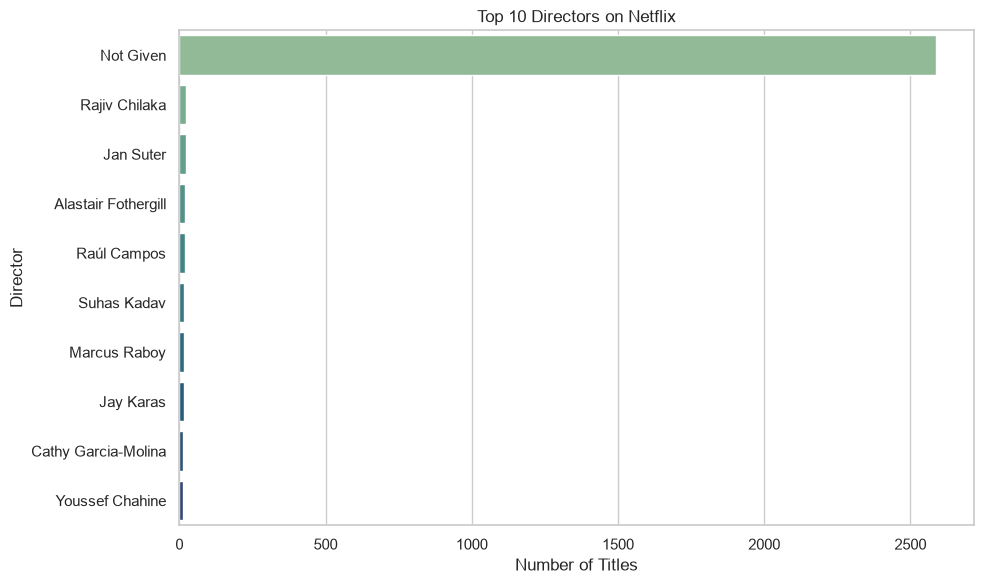

In [14]:
# ==========================================================
# Cell 14: Top 10 Directors Analysis
# ==========================================================

print("=" * 70)
print("TOP 10 DIRECTORS")
print("=" * 70)


if "director" in df.columns:

    director_data = (
        df["director"]
        .dropna()
        .str.split(", ")
        .explode()
    )

    top_directors = director_data.value_counts().head(10)

    display(
        top_directors.reset_index()
        .rename(columns={
            "director":"Director",
            "count":"Number of Titles"
        })
    )


    plt.figure(figsize=(10,6))

    sns.barplot(
        x=top_directors.values,
        y=top_directors.index,
        palette="crest"
    )

    plt.title("Top 10 Directors on Netflix")
    plt.xlabel("Number of Titles")
    plt.ylabel("Director")

    plt.tight_layout()
    plt.show()

else:
    print("Director column not available")

YEARLY CONTENT ADDITION TREND


,Year,Titles Added
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,426
9,2017,1185


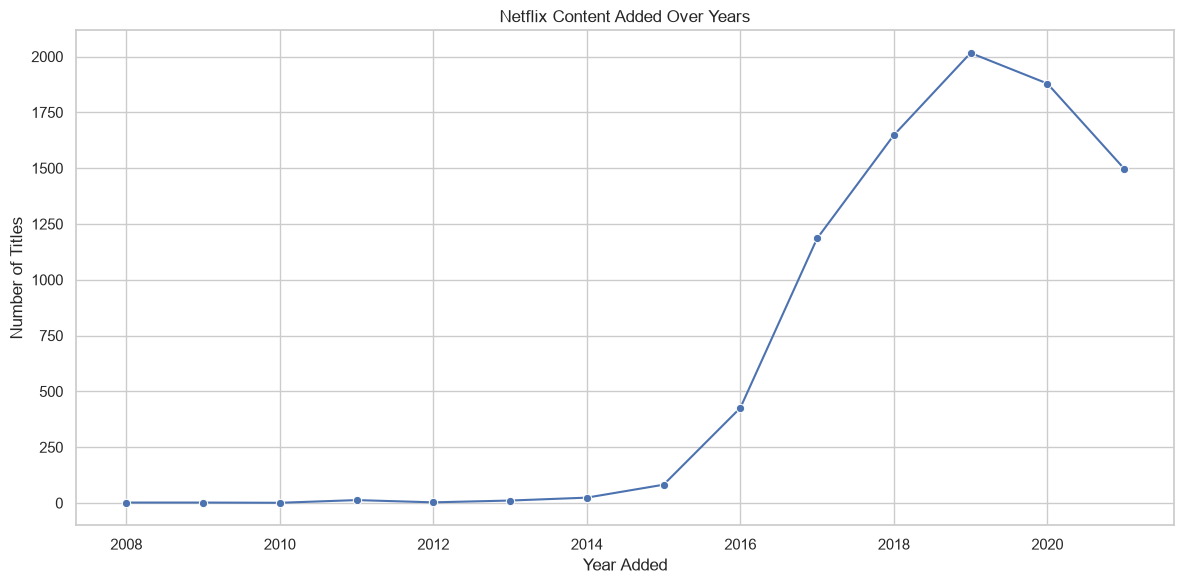

In [15]:
# ==========================================================
# Cell 15: Content Addition Trend Analysis
# ==========================================================

print("=" * 70)
print("YEARLY CONTENT ADDITION TREND")
print("=" * 70)


if "added_year" in df.columns:

    yearly_added = (
        df["added_year"]
        .value_counts()
        .sort_index()
    )


    display(
        yearly_added.reset_index()
        .rename(columns={
            "added_year":"Year",
            "count":"Titles Added"
        })
    )


    plt.figure(figsize=(12,6))

    sns.lineplot(
        x=yearly_added.index,
        y=yearly_added.values,
        marker="o"
    )

    plt.title("Netflix Content Added Over Years")
    plt.xlabel("Year Added")
    plt.ylabel("Number of Titles")

    plt.grid(True)

    plt.tight_layout()
    plt.show()

else:
    print("added_year feature not available")

NUMERICAL FEATURE CORRELATION


,release_year,content_age,movie_duration,decade
release_year,1.000000,-1.000000,-0.249988,0.940166
content_age,-1.000000,1.000000,0.249988,-0.940166
movie_duration,-0.249988,0.249988,1.000000,-0.251837
decade,0.940166,-0.940166,-0.251837,1.000000


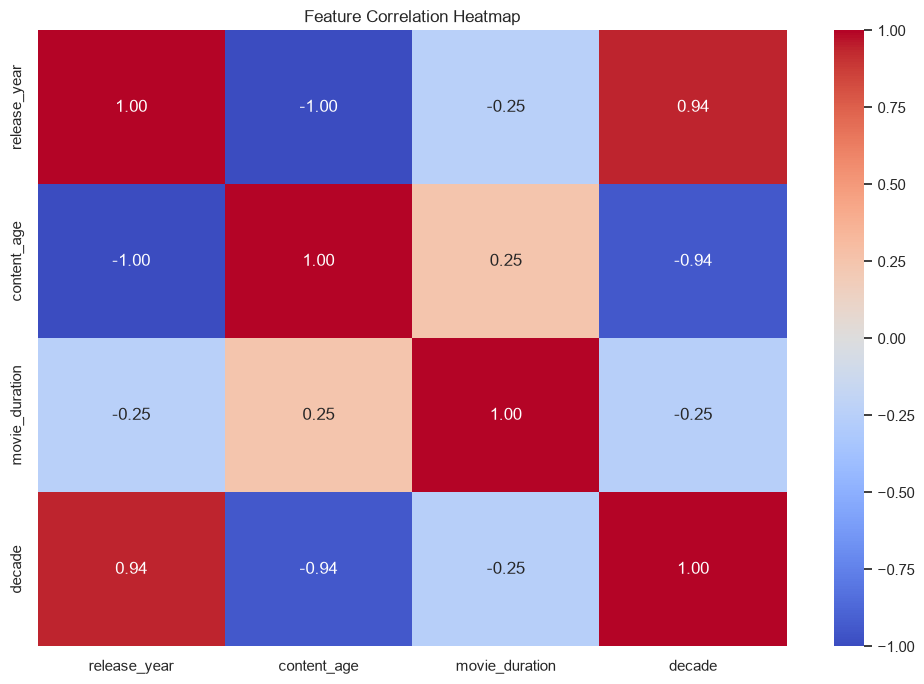

In [16]:
# ==========================================================
# Cell 16: Correlation Analysis
# ==========================================================

print("=" * 70)
print("NUMERICAL FEATURE CORRELATION")
print("=" * 70)


numeric_df = df.select_dtypes(
    include=["int64","float64"]
)


correlation = numeric_df.corr()


display(correlation)


plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [17]:
# ==========================================================
# Cell 17: Data Quality Report Export
# ==========================================================

print("=" * 70)
print("GENERATING DATA QUALITY REPORT")
print("=" * 70)

data_quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    "Unique Values": df.nunique().values
})


display(data_quality_report)


# Create output folder

os.makedirs("outputs", exist_ok=True)


data_quality_report.to_csv(
    "outputs/data_quality_report.csv",
    index=False
)


print("Data Quality Report Saved Successfully")

GENERATING DATA QUALITY REPORT


,Column,Data Type,Missing Values,Missing Percentage,Unique Values
0,show_id,str,0,0.0,8790
1,type,str,0,0.0,2
2,title,str,0,0.0,8787
3,director,str,0,0.0,4528
4,country,str,0,0.0,86
5,date_added,datetime64[us],0,0.0,1713
6,release_year,int64,0,0.0,74
7,rating,str,0,0.0,14
8,duration,str,0,0.0,220
9,listed_in,str,0,0.0,513


Data Quality Report Saved Successfully


In [18]:
# ==========================================================
# Cell 18: KPI Summary Export
# ==========================================================

print("=" * 70)
print("EXPORTING BUSINESS KPI SUMMARY")
print("=" * 70)


kpi_summary = pd.DataFrame(
    {
        "Metric": list(kpis.keys()),
        "Value": list(kpis.values())
    }
)


display(kpi_summary)


kpi_summary.to_csv(
    "outputs/kpi_summary.csv",
    index=False
)


print("KPI Summary Saved Successfully")

EXPORTING BUSINESS KPI SUMMARY


,Metric,Value
0,Total Titles,8790.00
1,Movies,6126.00
2,TV Shows,2664.00
3,Unique Countries,86.00
4,Unique Directors,4528.00
5,Unique Genres,513.00
6,Earliest Release Year,1925.00
7,Latest Release Year,2021.00
8,Average Release Year,2014.18


KPI Summary Saved Successfully


In [19]:
# ==========================================================
# Cell 19: Country Market Analysis
# ==========================================================

print("=" * 70)
print("COUNTRY MARKET ANALYSIS")
print("=" * 70)


country_analysis = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)


country_analysis.columns = [
    "Country",
    "Number_of_Titles"
]


display(country_analysis.head(10))


country_analysis.to_csv(
    "outputs/country_analysis.csv",
    index=False
)


print("Country Analysis Saved")

COUNTRY MARKET ANALYSIS


,Country,Number_of_Titles
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Not Given,287
5,Canada,271
6,Japan,259
7,South Korea,214
8,France,213
9,Spain,182


Country Analysis Saved


In [20]:
# ==========================================================
# Cell 20: Genre Performance Analysis
# ==========================================================

print("=" * 70)
print("GENRE PERFORMANCE ANALYSIS")
print("=" * 70)


genre_analysis = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)


genre_analysis.columns = [
    "Genre",
    "Number_of_Titles"
]


display(genre_analysis.head(10))


genre_analysis.to_csv(
    "outputs/genre_analysis.csv",
    index=False
)


print("Genre Analysis Saved")

GENRE PERFORMANCE ANALYSIS


,Genre,Number_of_Titles
0,International Movies,2752
1,Dramas,2426
2,Comedies,1674
3,International TV Shows,1349
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


Genre Analysis Saved


In [21]:
# ==========================================================
# Cell 21: Business Insights Generator
# ==========================================================

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)


insights = []


# Content Type Insight

movie_percentage = (
    (df["type"] == "Movie").sum()
    / len(df) * 100
)


insights.append(
    f"Movies represent {movie_percentage:.2f}% of Netflix content."
)


# Country Insight

top_country = country_analysis.iloc[0]["Country"]

insights.append(
    f"{top_country} is the leading content producing country."
)


# Genre Insight

top_genre = genre_analysis.iloc[0]["Genre"]

insights.append(
    f"{top_genre} is the most common genre available on Netflix."
)


# Release Trend

latest_year = df["release_year"].max()

insights.append(
    f"Netflix contains content released up to {latest_year}."
)


for i, insight in enumerate(insights,1):
    print(f"{i}. {insight}")


with open(
    "outputs/business_insights.txt",
    "w",
    encoding="utf-8"
) as file:

    for insight in insights:
        file.write(insight + "\n")


print("\nBusiness Insights Saved")

BUSINESS INSIGHTS
1. Movies represent 69.69% of Netflix content.
2. United States is the leading content producing country.
3. International Movies is the most common genre available on Netflix.
4. Netflix contains content released up to 2021.

Business Insights Saved


In [22]:
# ==========================================================
# Cell 22: Save Final Processed Dataset
# ==========================================================

print("=" * 70)
print("EXPORTING FINAL DATASET")
print("=" * 70)


df.to_csv(
    "outputs/final_netflix_business_dataset.csv",
    index=False
)


print(
    "Final Dataset Shape:",
    df.shape
)


print(
    "\nFile Saved Successfully:"
)

print(
    "outputs/final_netflix_business_dataset.csv"
)

EXPORTING FINAL DATASET
Final Dataset Shape: (8790, 16)

File Saved Successfully:
outputs/final_netflix_business_dataset.csv


In [23]:
# ==========================================================
# Cell 23: Project Summary Report
# ==========================================================

print("=" * 80)
print("TASK 6 - DATA SCIENCE BUSINESS INTELLIGENCE DASHBOARD")
print("PART 1 COMPLETION REPORT")
print("=" * 80)


summary = {
    "Dataset Name": "Netflix Clean Dataset",
    "Total Records": len(df),
    "Total Features": len(df.columns),
    "Movies Count": (df["type"] == "Movie").sum(),
    "TV Shows Count": (df["type"] == "TV Show").sum(),
    "Countries Covered": df["country"].nunique(),
    "Genres Available": df["listed_in"].nunique(),
    "Latest Release Year": df["release_year"].max(),
    "Earliest Release Year": df["release_year"].min(),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Records": df.duplicated().sum()
}


summary_df = pd.DataFrame(
    summary.items(),
    columns=["Analysis Metric", "Value"]
)


display(summary_df)


# Save project summary

summary_df.to_csv(
    "outputs/project_summary_report.csv",
    index=False
)


print("\n" + "=" * 80)
print("PART 1 COMPLETED SUCCESSFULLY")
print("=" * 80)


print("""
Completed Modules:

✓ Dataset Loading
✓ Data Quality Assessment
✓ Data Cleaning
✓ Feature Engineering
✓ Exploratory Data Analysis
✓ Business KPI Analysis
✓ Market Analysis
✓ Genre Analysis
✓ Trend Analysis
✓ Insight Generation
✓ Report Export

Next Phase:
Advanced Interactive Business Intelligence Dashboard
""")

TASK 6 - DATA SCIENCE BUSINESS INTELLIGENCE DASHBOARD
PART 1 COMPLETION REPORT


,Analysis Metric,Value
0,Dataset Name,Netflix Clean Dataset
1,Total Records,8790
2,Total Features,16
3,Movies Count,6126
4,TV Shows Count,2664
5,Countries Covered,86
6,Genres Available,513
7,Latest Release Year,2021
8,Earliest Release Year,1925
9,Missing Values,0



PART 1 COMPLETED SUCCESSFULLY

Completed Modules:

✓ Dataset Loading
✓ Data Quality Assessment
✓ Data Cleaning
✓ Feature Engineering
✓ Exploratory Data Analysis
✓ Business KPI Analysis
✓ Market Analysis
✓ Genre Analysis
✓ Trend Analysis
✓ Insight Generation
✓ Report Export

Next Phase:
Advanced Interactive Business Intelligence Dashboard



In [24]:
# ==========================================================
# Cell 24: Dashboard Library Setup
# ==========================================================

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("=" * 70)
print("PLOTLY DASHBOARD ENVIRONMENT READY")
print("=" * 70)

PLOTLY DASHBOARD ENVIRONMENT READY


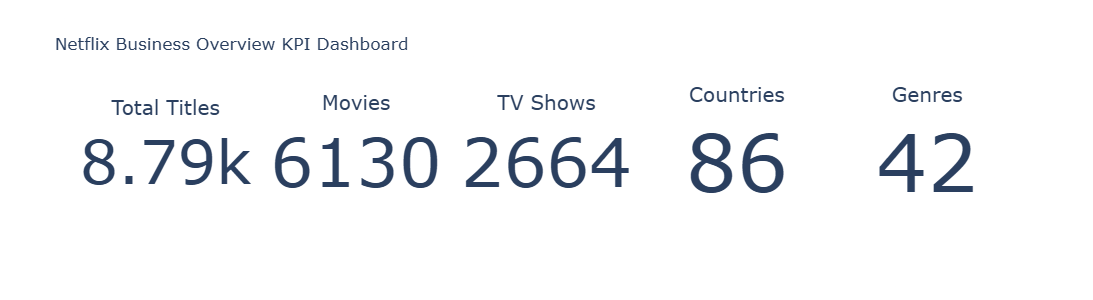

In [25]:
# ==========================================================
# Cell 25: Executive KPI Cards
# ==========================================================

total_titles = len(df)

movies = (df["type"] == "Movie").sum()

tv_shows = (df["type"] == "TV Show").sum()

countries = df["country"].nunique()

genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .nunique()
)


fig = go.Figure()


kpi_values = [
    ("Total Titles", total_titles),
    ("Movies", movies),
    ("TV Shows", tv_shows),
    ("Countries", countries),
    ("Genres", genres)
]


for i, (label, value) in enumerate(kpi_values):

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=value,
            title={"text": label},
            domain={
                "row":0,
                "column":i
            }
        )
    )


fig.update_layout(
    grid={
        "rows":1,
        "columns":5
    },
    title="Netflix Business Overview KPI Dashboard",
    height=300
)


fig.show()

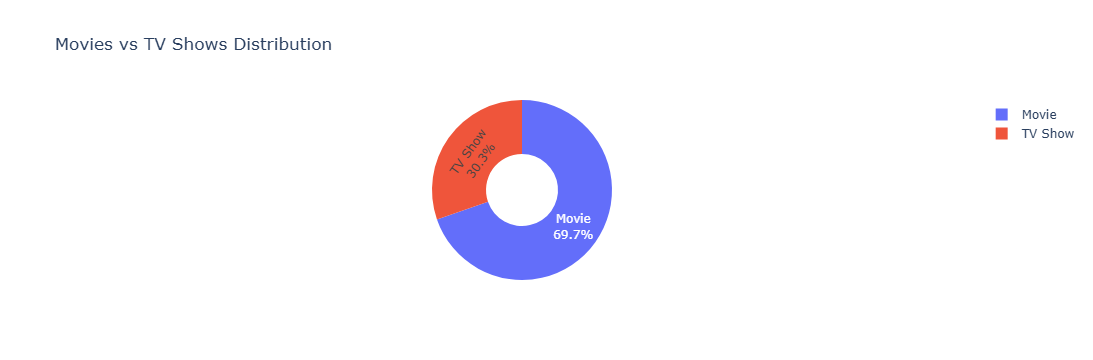

In [26]:
# ==========================================================
# Cell 26: Content Type Analysis
# ==========================================================

type_analysis = (
    df["type"]
    .value_counts()
    .reset_index()
)

type_analysis.columns = [
    "Content Type",
    "Count"
]


fig = px.pie(
    type_analysis,
    names="Content Type",
    values="Count",
    hole=0.4,
    title="Movies vs TV Shows Distribution"
)


fig.update_traces(
    textinfo="percent+label"
)


fig.show()

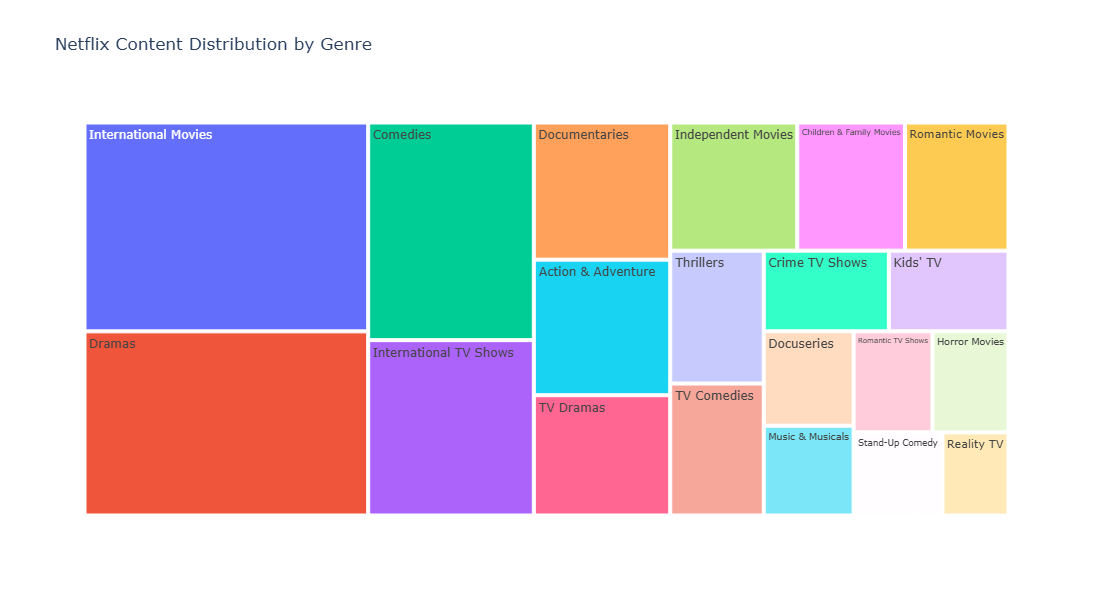

In [27]:
# ==========================================================
# Cell 27: Genre Treemap Visualization
# ==========================================================

genre_dashboard = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)


genre_dashboard.columns = [
    "Genre",
    "Titles"
]


genre_dashboard = genre_dashboard.head(20)


fig = px.treemap(
    genre_dashboard,
    path=["Genre"],
    values="Titles",
    title="Netflix Content Distribution by Genre"
)


fig.update_layout(
    height=600
)


fig.show()

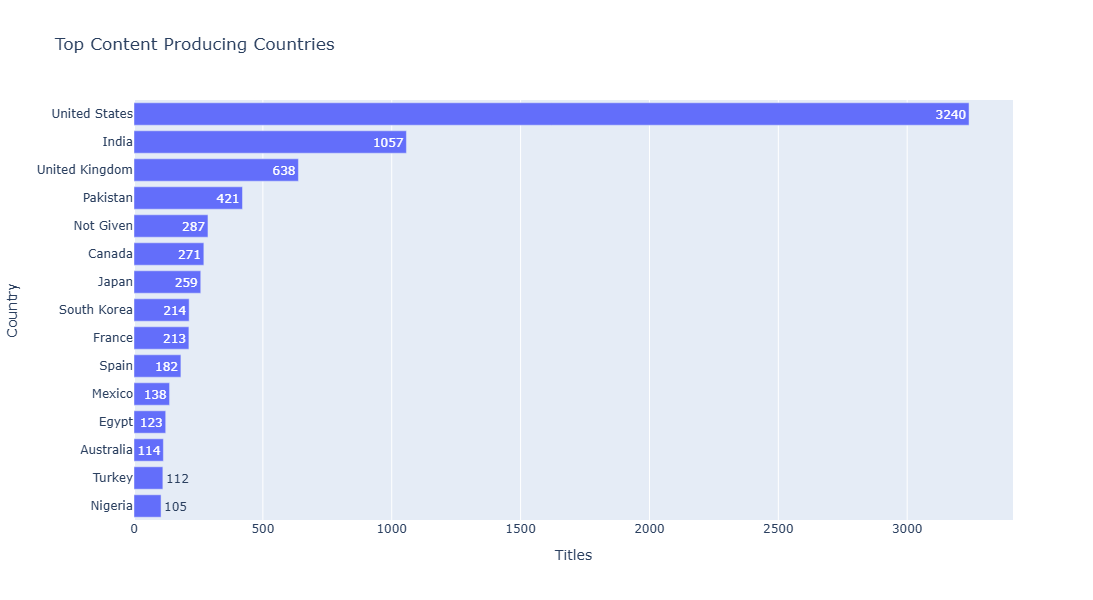

In [28]:
# ==========================================================
# Cell 28: Country Market Analysis
# ==========================================================

country_dashboard = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)


country_dashboard.columns = [
    "Country",
    "Titles"
]


country_dashboard = country_dashboard.head(15)


fig = px.bar(
    country_dashboard,
    x="Titles",
    y="Country",
    orientation="h",
    title="Top Content Producing Countries",
    text="Titles"
)


fig.update_layout(
    height=600,
    yaxis={
        "categoryorder":"total ascending"
    }
)


fig.show()

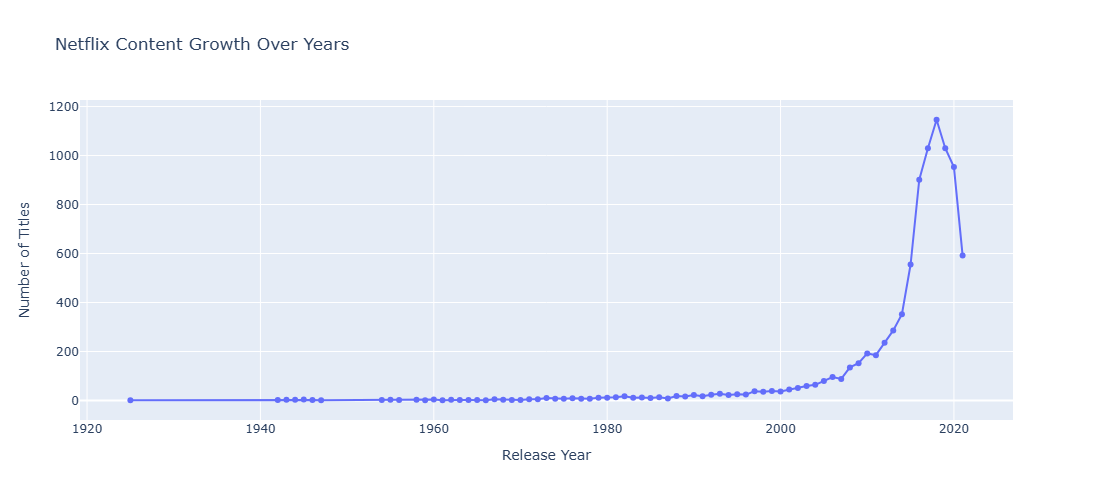

In [29]:
# ==========================================================
# Cell 29: Release Year Trend
# ==========================================================

year_analysis = (
    df["release_year"]
    .value_counts()
    .sort_index()
    .reset_index()
)


year_analysis.columns = [
    "Release Year",
    "Number of Titles"
]


fig = px.line(
    year_analysis,
    x="Release Year",
    y="Number of Titles",
    markers=True,
    title="Netflix Content Growth Over Years"
)


fig.update_layout(
    height=500
)


fig.show()

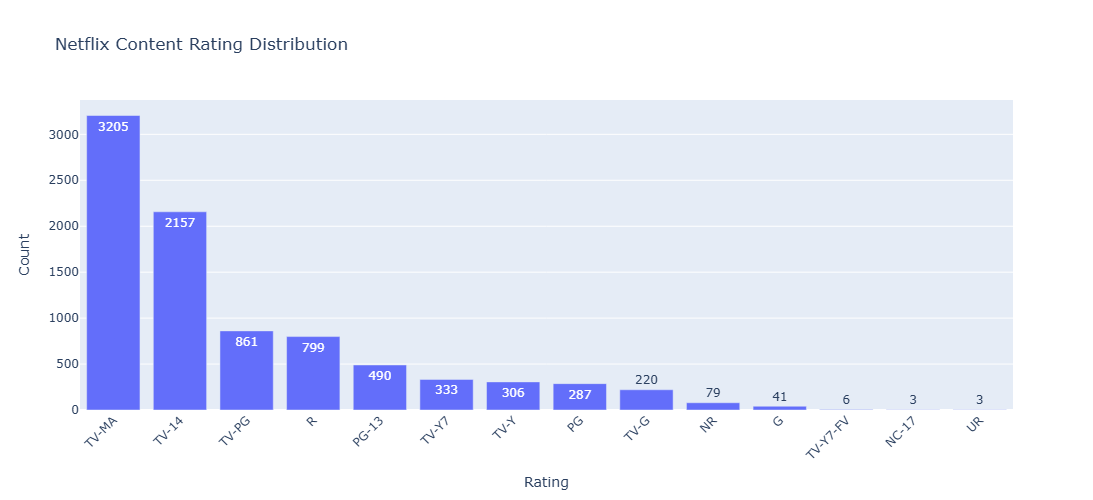

In [30]:
# ==========================================================
# Cell 30: Rating Analysis
# ==========================================================

rating_dashboard = (
    df["rating"]
    .value_counts()
    .reset_index()
)


rating_dashboard.columns = [
    "Rating",
    "Count"
]


fig = px.bar(
    rating_dashboard,
    x="Rating",
    y="Count",
    title="Netflix Content Rating Distribution",
    text="Count"
)


fig.update_layout(
    xaxis_tickangle=-45,
    height=500
)


fig.show()

In [31]:
# ==========================================================
# Cell 31: Export Interactive Dashboard
# ==========================================================

dashboard_file = "Netflix_Business_Intelligence_Dashboard.html"


fig.write_html(
    dashboard_file
)


print("=" * 70)
print("DASHBOARD EXPORTED SUCCESSFULLY")
print("=" * 70)

print(
    f"File Created: {dashboard_file}"
)

DASHBOARD EXPORTED SUCCESSFULLY
File Created: Netflix_Business_Intelligence_Dashboard.html


In [32]:
# ==========================================================
# Cell 32: Machine Learning Data Preparation
# ==========================================================

print("=" * 70)
print("PREPARING DATA FOR CLUSTERING")
print("=" * 70)


ml_features = df[
    [
        "release_year",
        "content_age",
        "movie_duration"
    ]
].copy()


# Fill missing values

ml_features = ml_features.fillna(
    ml_features.median()
)


display(ml_features.head())


print("ML Dataset Shape:", ml_features.shape)

PREPARING DATA FOR CLUSTERING


,release_year,content_age,movie_duration
0,2020,6,90.0
1,2021,5,1.0
2,2021,5,1.0
3,2021,5,91.0
4,1993,33,125.0


ML Dataset Shape: (8790, 3)


In [33]:
# ==========================================================
# Cell 33: Feature Scaling
# ==========================================================

scaler = StandardScaler()


scaled_features = scaler.fit_transform(
    ml_features
)


print("=" * 70)
print("FEATURE SCALING COMPLETED")
print("=" * 70)


print(
    "Scaled Data Shape:",
    scaled_features.shape
)

FEATURE SCALING COMPLETED
Scaled Data Shape: (8790, 3)


In [34]:
# ==========================================================
# Cell 34: KMeans Clustering
# ==========================================================

print("=" * 70)
print("CONTENT CLUSTERING")
print("=" * 70)


kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)


clusters = kmeans.fit_predict(
    scaled_features
)


df["content_cluster"] = clusters


print(
    "Clusters Created Successfully"
)


display(
    df[
        [
            "title",
            "release_year",
            "content_cluster"
        ]
    ].head()
)

CONTENT CLUSTERING
Clusters Created Successfully


,title,release_year,content_cluster
0,Dick Johnson Is Dead,2020,0
1,Ganglands,2021,3
2,Midnight Mass,2021,3
3,Confessions of an Invisible Girl,2021,0
4,Sankofa,1993,1


In [40]:
# ==========================================================
# Cell 35: PCA Cluster Visualization (WebGL Fix)
# ==========================================================

import plotly.io as pio

# Use browser renderer
pio.renderers.default = "browser"


pca = PCA(
    n_components=2
)


pca_data = pca.fit_transform(
    scaled_features
)


pca_df = pd.DataFrame(
    pca_data,
    columns=[
        "PCA1",
        "PCA2"
    ]
)


pca_df["Cluster"] = clusters.astype(str)


fig = px.scatter(
    pca_df,
    x="PCA1",
    y="PCA2",
    color="Cluster",
    title="Netflix Content Segmentation using KMeans",
    render_mode="svg"
)


fig.update_layout(
    height=600,
    template="plotly_white"
)


fig.show()

In [36]:
# ==========================================================
# Cell 36: Cluster Analysis
# ==========================================================

print("=" * 70)
print("CLUSTER BUSINESS ANALYSIS")
print("=" * 70)


cluster_summary = (
    df.groupby("content_cluster")
    [
        [
            "release_year",
            "content_age",
            "movie_duration"
        ]
    ]
    .mean()
    .round(2)
)


display(cluster_summary)


cluster_summary.to_csv(
    "outputs/content_cluster_analysis.csv"
)

CLUSTER BUSINESS ANALYSIS


,release_year,content_age,movie_duration
content_cluster,,,
0,2016.92,9.08,99.96
1,2003.83,22.17,105.45
2,1977.24,48.76,108.29
3,2017.38,8.62,5.02


In [37]:
# ==========================================================
# Cell 37: Business Recommendation Engine
# ==========================================================


recommendations = []


# Genre Recommendation

top_genre = genre_analysis.iloc[0]["Genre"]

recommendations.append(
    f"Increase investment in {top_genre} genre because it has the highest content availability."
)


# Country Recommendation

top_market = country_analysis.iloc[0]["Country"]

recommendations.append(
    f"Expand content acquisition strategies in {top_market} market."
)


# Content Type Recommendation

if movies > tv_shows:

    recommendations.append(
        "Netflix has more movie content. Increasing TV Show production can improve content balance."
    )

else:

    recommendations.append(
        "TV Shows dominate the platform. Continue investing in serialized content."
    )


# Trend Recommendation

recommendations.append(
    "Analyze recent release trends to identify emerging audience preferences."
)


print("=" * 70)
print("BUSINESS RECOMMENDATIONS")
print("=" * 70)


for i, recommendation in enumerate(
    recommendations,
    1
):
    print(
        f"{i}. {recommendation}"
    )


pd.DataFrame(
    {
        "Recommendation": recommendations
    }
).to_csv(
    "outputs/business_recommendations.csv",
    index=False
)

BUSINESS RECOMMENDATIONS
1. Increase investment in International Movies genre because it has the highest content availability.
2. Expand content acquisition strategies in United States market.
3. Netflix has more movie content. Increasing TV Show production can improve content balance.
4. Analyze recent release trends to identify emerging audience preferences.


In [38]:
# ==========================================================
# Cell 38: Executive Summary Report
# ==========================================================


summary_text = f"""

NETFLIX BUSINESS INTELLIGENCE REPORT
====================================


Dataset Overview:

Total Titles: {len(df)}

Movies: {movies}

TV Shows: {tv_shows}

Countries Covered: {countries}

Genres Available: {genres}



Key Findings:

1. {top_genre} is the most common content category.

2. {top_market} produces the highest amount of Netflix content.

3. Netflix contains content from {df['release_year'].min()} to {df['release_year'].max()}.

4. Machine learning clustering identified {df['content_cluster'].nunique()} content segments.



Business Recommendations:

"""


for rec in recommendations:
    summary_text += "\n- " + rec



with open(
    "outputs/executive_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(summary_text)



print(summary_text)



NETFLIX BUSINESS INTELLIGENCE REPORT


Dataset Overview:

Total Titles: 8790

Movies: 6126

TV Shows: 2664

Countries Covered: 86

Genres Available: 42



Key Findings:

1. International Movies is the most common content category.

2. United States produces the highest amount of Netflix content.

3. Netflix contains content from 1925 to 2021.

4. Machine learning clustering identified 4 content segments.



Business Recommendations:


- Increase investment in International Movies genre because it has the highest content availability.
- Expand content acquisition strategies in United States market.
- Netflix has more movie content. Increasing TV Show production can improve content balance.
- Analyze recent release trends to identify emerging audience preferences.


In [39]:
# ==========================================================
# Cell 39: Final Dataset Export
# ==========================================================


df.to_csv(
    "outputs/final_business_intelligence_dataset.csv",
    index=False
)


print("=" * 70)
print("TASK 6 FINAL PROJECT COMPLETED")
print("=" * 70)


print("""
Deliverables Generated:

✓ Interactive Dashboard
✓ KPI Analysis
✓ Business Insights
✓ ML Content Segmentation
✓ PCA Visualization
✓ Recommendation Engine
✓ Executive Summary
✓ Final Dataset

Project Ready For:
- GitHub Portfolio
- LinkedIn Showcase
- Internship Submission
""")

TASK 6 FINAL PROJECT COMPLETED

Deliverables Generated:

✓ Interactive Dashboard
✓ KPI Analysis
✓ Business Insights
✓ ML Content Segmentation
✓ PCA Visualization
✓ Recommendation Engine
✓ Executive Summary
✓ Final Dataset

Project Ready For:
- GitHub Portfolio
- LinkedIn Showcase
- Internship Submission

